# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [2]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7041 - loss: 0.5602 - val_accuracy: 0.7863 - val_loss: 0.4608
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7917 - loss: 0.4519 - val_accuracy: 0.7902 - val_loss: 0.4505
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7943 - loss: 0.4459 - val_accuracy: 0.7917 - val_loss: 0.4476
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7963 - loss: 0.4419 - val_accuracy: 0.7950 - val_loss: 0.4428
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7977 - loss: 0.4391 - val_accuracy: 0.7958 - val_loss: 0.4405
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7986 - loss: 0.4378 - val_accuracy: 0.7955 - val_loss: 0.4399
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7988 - loss: 0.4368 - val_accuracy: 0.7957 - val_loss: 0.4390
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7991 - loss: 0.4365 - val_accuracy: 0.

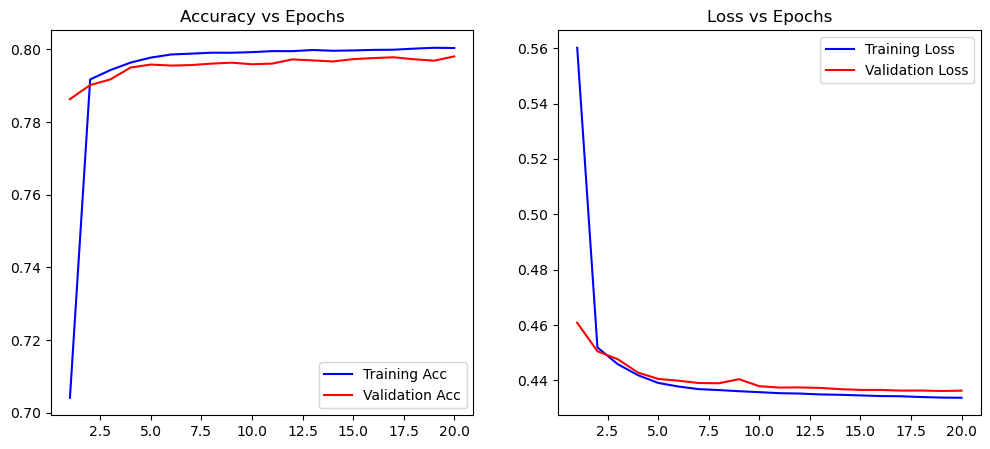

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier

def plot_history(history):
    """Function to plot training vs validation accuracy and loss"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Accuracy vs Epochs')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Loss vs Epochs')
    plt.legend()
    plt.show()

# Building Baseline Model
model_baseline = Sequential([
    Dense(12, input_dim=X_Train.shape[1], activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_baseline.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training for 20 epochs to check for plateau
history_baseline = model_baseline.fit(X_Train, y_Train, epochs=20, batch_size=1000, 
                                     validation_data=(X_Test, y_Test), verbose=1)

plot_history(history_baseline)

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

Training model for: Raw Data Only...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 455us/step
Training model for: Engineered Features Only...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 510us/step
Training model for: Combined (Raw + Features)...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step


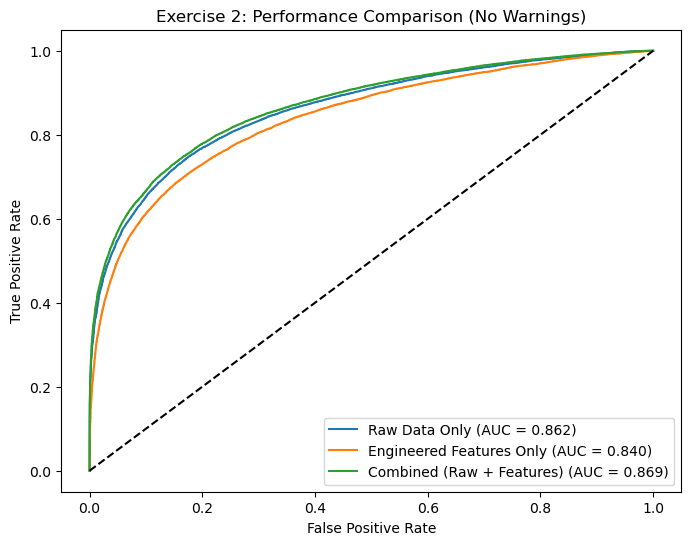

In [9]:
from tensorflow.keras.layers import Input
from sklearn.metrics import roc_curve, auc

# Defining the three sets to compare
comparison_sets = {
    "Raw Data Only": RawNames,
    "Engineered Features Only": FeatureNames,
    "Combined (Raw + Features)": VarNames[1:]
}

roc_results = {}

for label, columns in comparison_sets.items():
    print(f"Training model for: {label}...")
    
    X_tr = np.array(Train_Sample[columns])
    X_te = np.array(Test_Sample[columns])
    
    # Modern Keras Sequential structure using an Input object
    m = Sequential([
        Input(shape=(X_tr.shape[1],)),
        Dense(12, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    m.compile(loss='binary_crossentropy', optimizer='adam')
    m.fit(X_tr, y_Train, epochs=10, batch_size=2000, verbose=0)
    
    probs = m.predict(X_te)
    fpr, tpr, _ = roc_curve(y_Test, probs)
    roc_results[label] = (fpr, tpr, auc(fpr, tpr))

# Plotting results
plt.figure(figsize=(8, 6))
for label, (fpr, tpr, score) in roc_results.items():
    plt.plot(fpr, tpr, label=f'{label} (AUC = {score:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Exercise 2: Performance Comparison (No Warnings)')
plt.legend()
plt.show()

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

Training Deep Model (12-8-4)...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 518us/step
Training Wide Model (64)...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 492us/step
Training Tanh Activation Model (12-8)...
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 514us/step


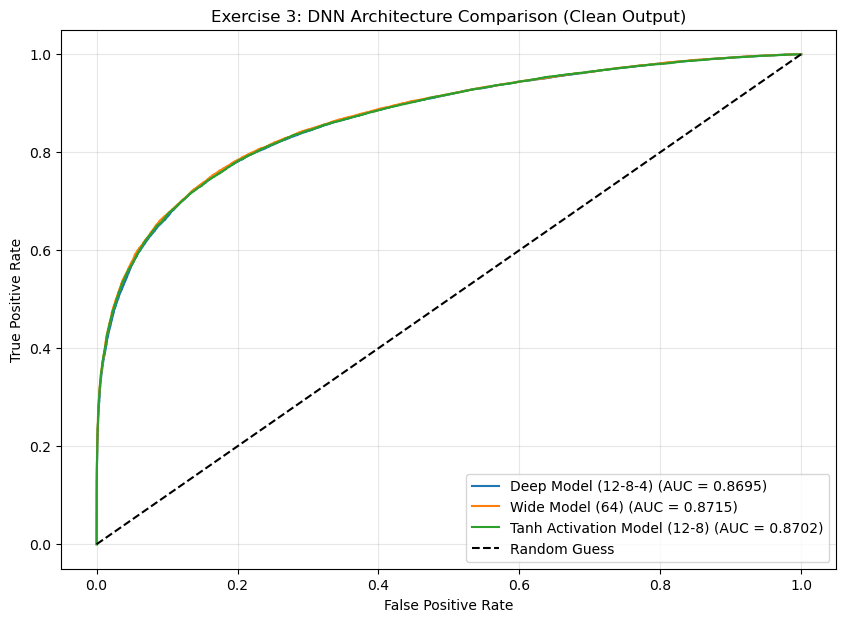

In [10]:
from tensorflow.keras.layers import Input
from sklearn.metrics import roc_curve, auc

# Defining three different architectures using the modern Input layer syntax
architectures = {
    "Deep Model (12-8-4)": Sequential([
        Input(shape=(X_Train.shape[1],)), # Explicitly defining the input shape
        Dense(12, activation='relu'),
        Dense(8, activation='relu'),
        Dense(4, activation='relu'),
        Dense(1, activation='sigmoid')
    ]),
    "Wide Model (64)": Sequential([
        Input(shape=(X_Train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ]),
    "Tanh Activation Model (12-8)": Sequential([
        Input(shape=(X_Train.shape[1],)),
        Dense(12, activation='tanh'),
        Dense(8, activation='tanh'),
        Dense(1, activation='sigmoid')
    ])
}

comparison_results = {}

for name, model in architectures.items():
    print(f"Training {name}...")
    
    # Using binary_crossentropy and adam optimizer as established in lecture
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    # Training for 10 epochs using a large batch size for efficiency
    model.fit(X_Train, y_Train, epochs=10, batch_size=2000, verbose=0)
    
    # Calculating performance metrics
    predictions = model.predict(X_Test)
    fpr, tpr, _ = roc_curve(y_Test, predictions)
    auc_score = auc(fpr, tpr)
    comparison_results[name] = (fpr, tpr, auc_score)

# --- Plotting Comparison ROC Curves ---
plt.figure(figsize=(10, 7))

for name, (fpr, tpr, auc_score) in comparison_results.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Exercise 3: DNN Architecture Comparison (Clean Output)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


Training Decision Tree...


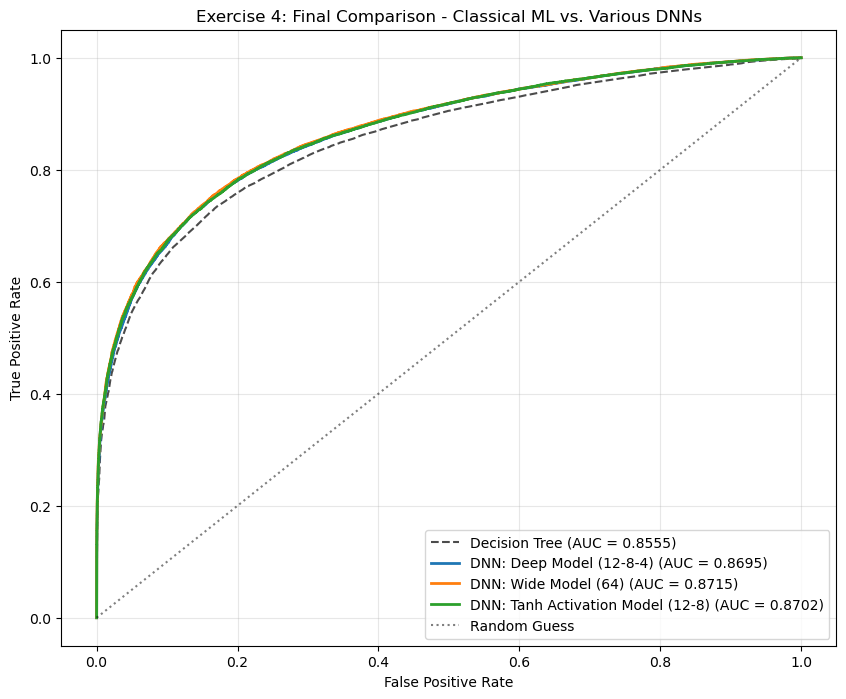


Final Performance Summary:
Decision Tree AUC: 0.8555
Deep Model (12-8-4) AUC: 0.8695
Wide Model (64) AUC: 0.8715
Tanh Activation Model (12-8) AUC: 0.8702


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

# 1. Training the Classical ML Model (Decision Tree)
# Using max_depth=10 as established in previous labs
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=10)
dt_model.fit(X_Train, y_Train)

dt_probs = dt_model.predict_proba(X_Test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_Test, dt_probs)
auc_dt = auc(fpr_dt, tpr_dt)

# 2. Plotting the Comparison (Decision Tree + All Exercise 3 DNNs)
plt.figure(figsize=(10, 8))

# Plotting the Decision Tree from Lab 8
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})', 
         linestyle='--', color='black', alpha=0.7)

# Plotting each DNN architecture from Exercise 3
# Note: 'comparison_results' contains the (fpr, tpr, auc) for each DNN
for name, (fpr, tpr, score) in comparison_results.items():
    plt.plot(fpr, tpr, label=f'DNN: {name} (AUC = {score:.4f})', linewidth=2)

# Final plot formatting
plt.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Exercise 4: Final Comparison - Classical ML vs. Various DNNs')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Print Final Summary Table
print("\nFinal Performance Summary:")
print(f"Decision Tree AUC: {auc_dt:.4f}")
for name, (_, _, score) in comparison_results.items():
    print(f"{name} AUC: {score:.4f}")